## Human Activity Recognition for Healthy Lifestyle Monitoring

First step is to pre-process the entire raw data

Below are the libraries used in this notebook

In [ ]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
import sys
import os
from pathlib import Path
import pandas as pd
import importlib
from src.preprocessing import process_folder, detect_trim_bounds_rms_intersection
import  shutil
import matplotlib.pyplot as plt
import numpy as np
import src.preprocessing
importlib.reload(src.preprocessing)  # for debugging

from src.preprocessing import detect_trim_bounds_rms_intersection


# Add the src folder to the Python module search path
sys.path.append(os.path.abspath("src"))
PROJECT_ROOT = Path.cwd().resolve()
RAW_BASE   = PROJECT_ROOT / "data" / "raw"
TRIMMED_BASE = PROJECT_ROOT / "data" / "trimmed_data"


from data_loader import load_all_data
from visualization import *
from preprocessing import *

sys.path.append(os.path.abspath("../src"))

# Load all data into memory
all_data = load_all_data()
#print("Data loaded. Available activities:", list(all_data.keys()))
print("All data loaded.")


Loading C:\Users\ozdep\Documents\data analytics\Data-Analytics-and-Learning-Methods\data\raw\running\Berkan_Run_1\Accelerometer.csv...
Loading C:\Users\ozdep\Documents\data analytics\Data-Analytics-and-Learning-Methods\data\raw\running\Berkan_Run_1\AccelerometerUncalibrated.csv...
Loading C:\Users\ozdep\Documents\data analytics\Data-Analytics-and-Learning-Methods\data\raw\running\Berkan_Run_1\Annotation.csv...
Could not load Annotation.csv: No columns to parse from file
Loading C:\Users\ozdep\Documents\data analytics\Data-Analytics-and-Learning-Methods\data\raw\running\Berkan_Run_1\Gravity.csv...
Loading C:\Users\ozdep\Documents\data analytics\Data-Analytics-and-Learning-Methods\data\raw\running\Berkan_Run_1\Gyroscope.csv...
Loading C:\Users\ozdep\Documents\data analytics\Data-Analytics-and-Learning-Methods\data\raw\running\Berkan_Run_1\GyroscopeUncalibrated.csv...
Loading C:\Users\ozdep\Documents\data analytics\Data-Analytics-and-Learning-Methods\data\raw\running\Berkan_Run_1\Metadata

### Data Collection Procedure

We used **two different methods** for collecting activity data:

1. **Continuous recordings**  
   - Applied to activities such as **running, walking, and climbing stairs**.  
   - These activities can be performed continuously without interruption.  
   - As a result, the recordings are relatively long.

2. **Single-instance recordings**  
   - Applied to **sitting down** and **standing up** activities.  
   - Each recording contains **only one instance** of the activity.  
   - These recordings are therefore relatively short.

Below are the visualized plots of **accelerometer**, **gyroscope**, and **gravity** sensor recordings from randomly selected samples of each activity group.

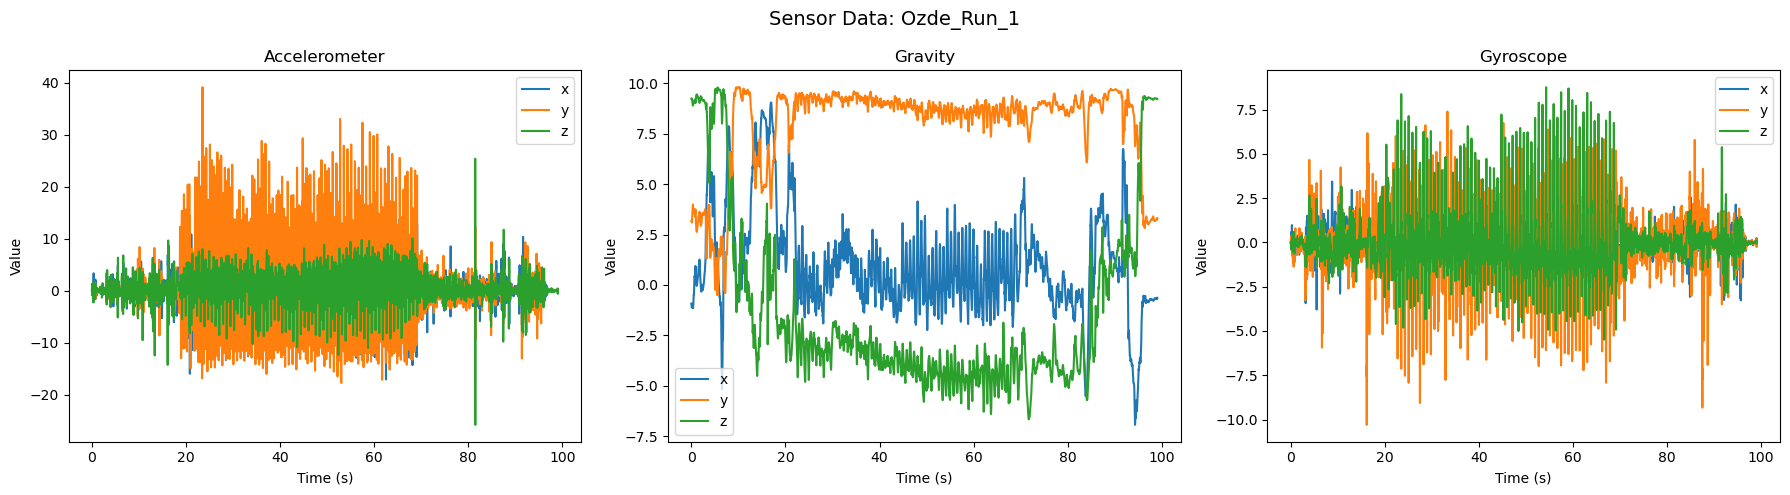

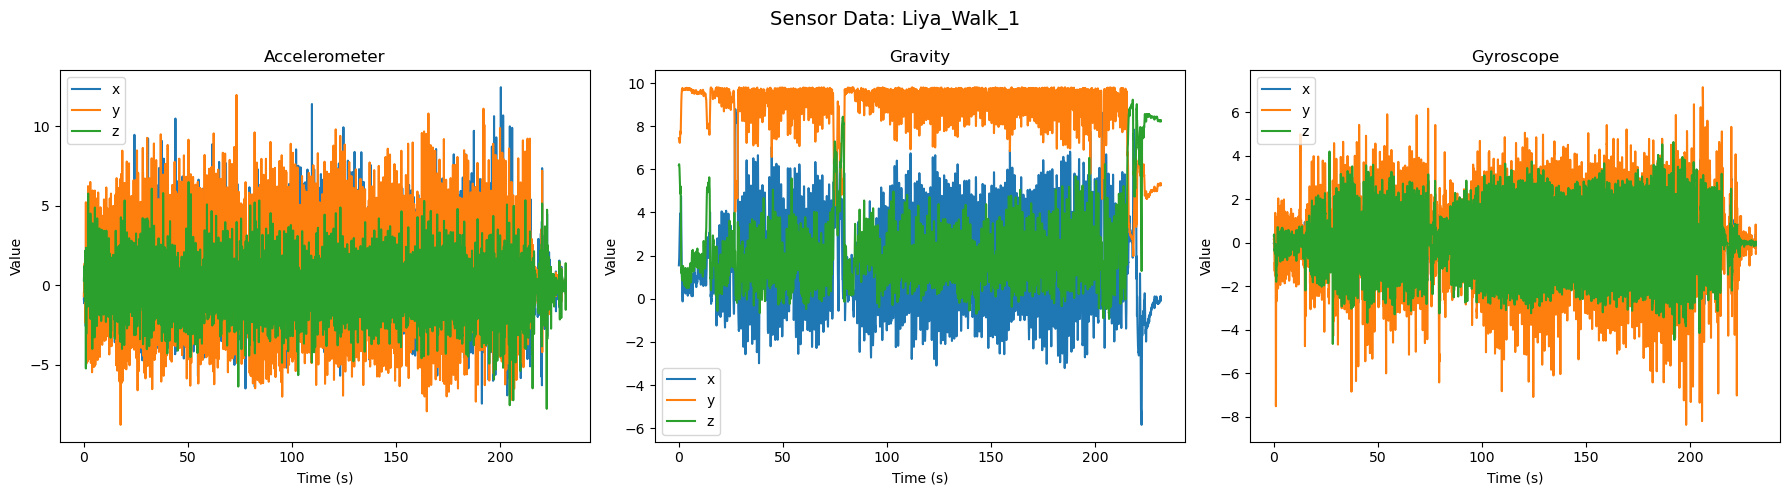

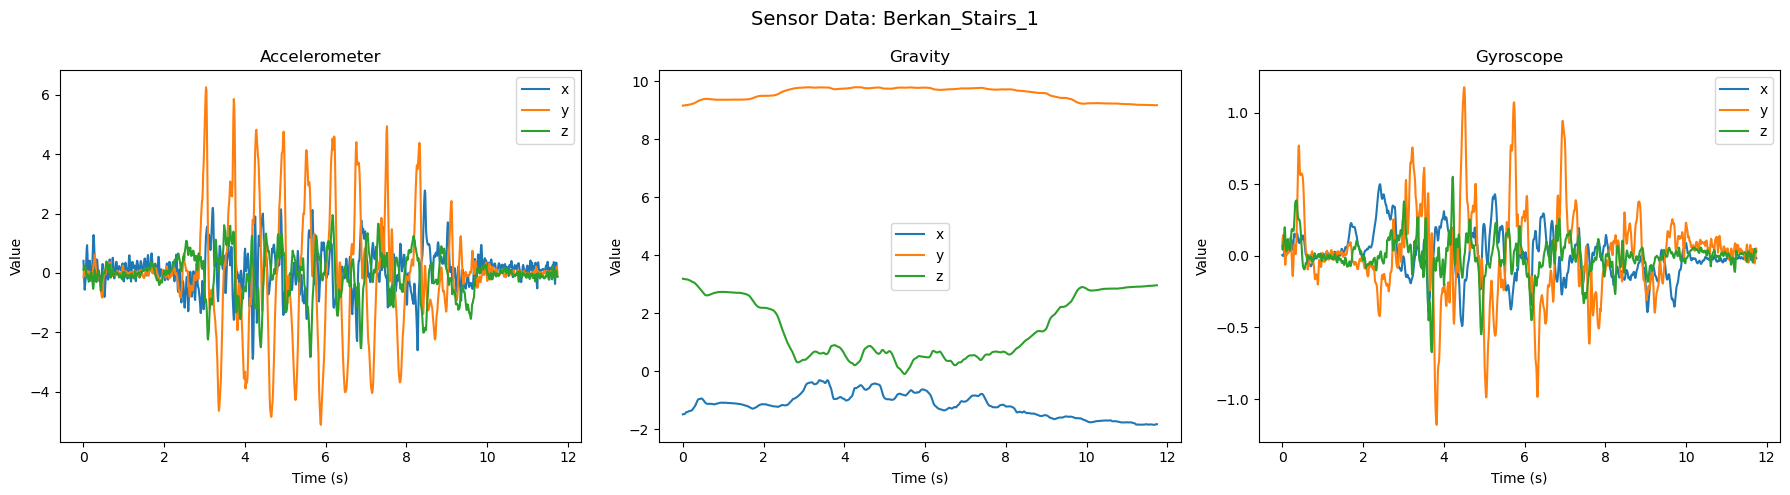

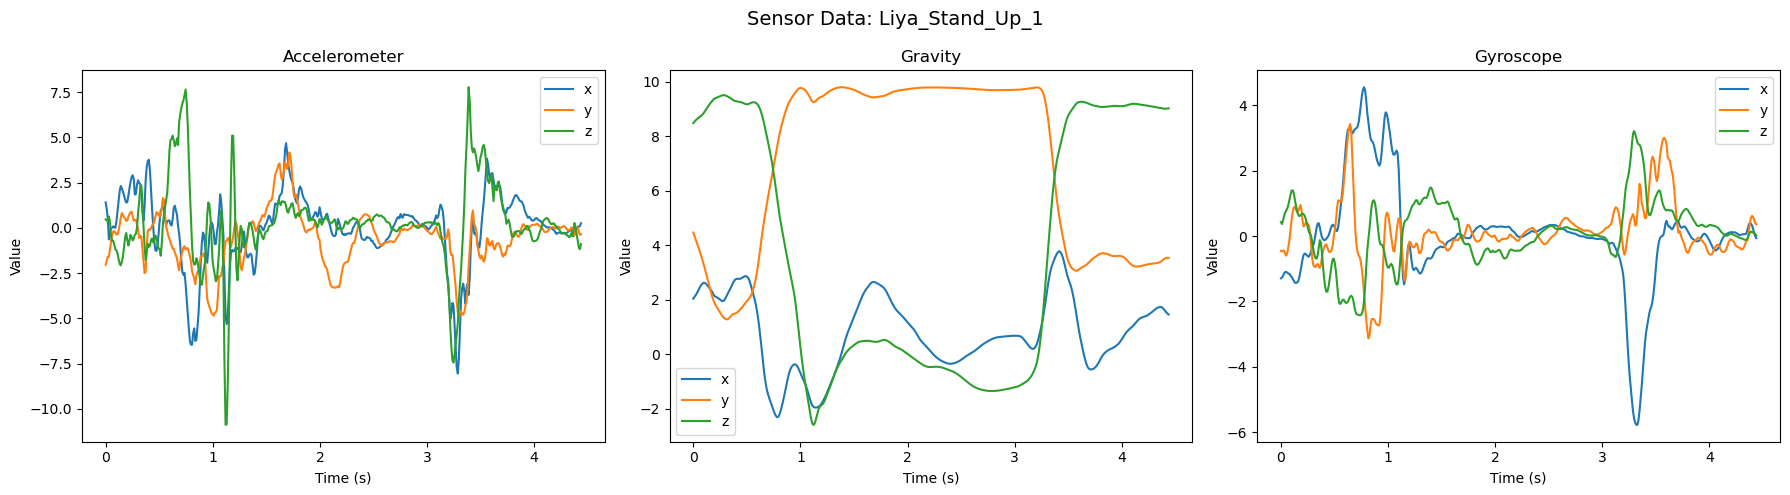

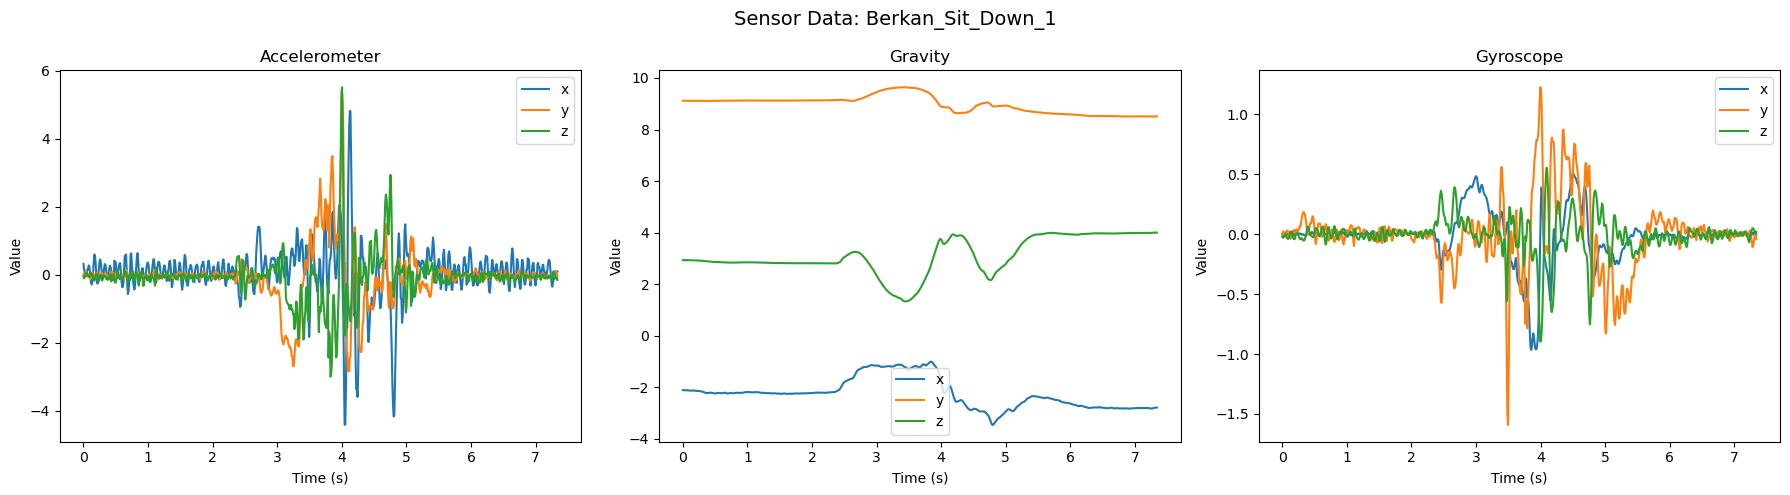

In [18]:
plot_activity(RAW_BASE / "running" / "Ozde_Run_1")
plot_activity(RAW_BASE / "walking" / "Liya_Walk_1")
plot_activity(RAW_BASE / "stairs" / "Berkan_Stairs_1")
plot_activity(RAW_BASE / "stand_up" / "Liya_Stand_Up_1")
plot_activity(RAW_BASE / "sit_down" / "Berkan_Sit_Down_1")

First, we need to remove the inactive portions at the start and end of each recording, keeping only the segment where the activity actually occurs.
The initial and final parts often contain noise because the recording starts before the participant begins moving.

Next, we must clean the data further by removing segments captured while placing the phone into the armband, as these movements are unrelated to the target activities.

- For Continuous activities (running / walking / climbing stairs):


=== Processing running | Folder: Berkan_Run_1 ===


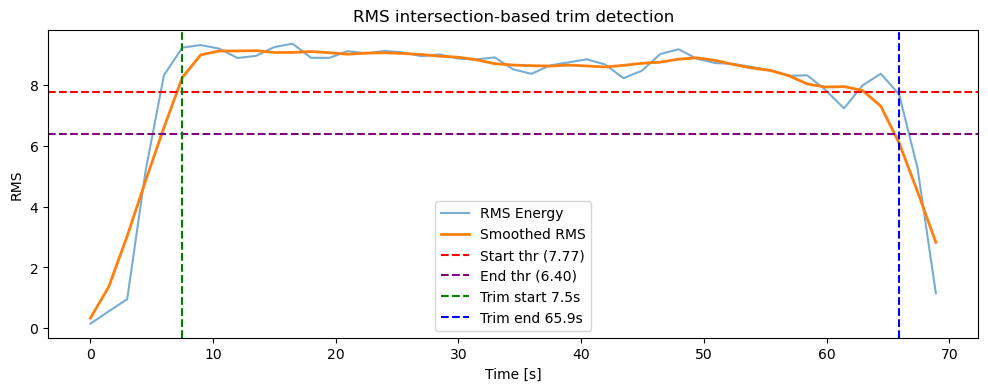

sample rate 100.18034876327567
step 500
stride 250
  Trim 7.50 → 62.41, 21 windows (multi-file) saved in c:\Users\ozdep\Documents\data analytics\data\trimmed_data\running\Berkan_Run_1

=== Processing running | Folder: Berkan_Run_2 ===


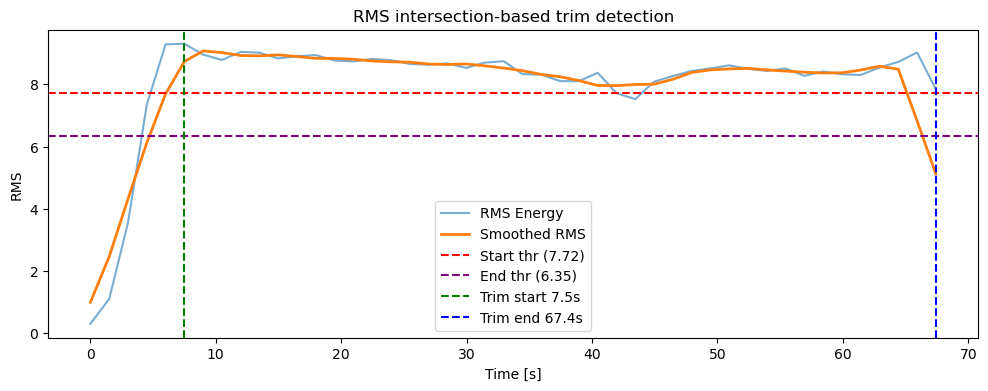

sample rate 100.1805440797707
step 500
stride 250
  Trim 7.51 → 64.91, 22 windows (multi-file) saved in c:\Users\ozdep\Documents\data analytics\data\trimmed_data\running\Berkan_Run_2

=== Processing running | Folder: Ozde_Run_1 ===


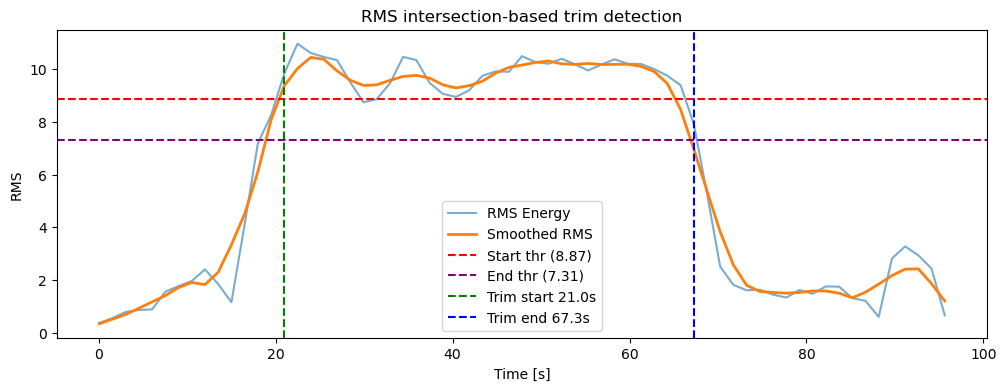

sample rate 100.44638197456707
step 502
stride 251
  Trim 20.05 → 67.53, 18 windows (multi-file) saved in c:\Users\ozdep\Documents\data analytics\data\trimmed_data\running\Ozde_Run_1

=== Processing running | Folder: Ozde_Run_2 ===


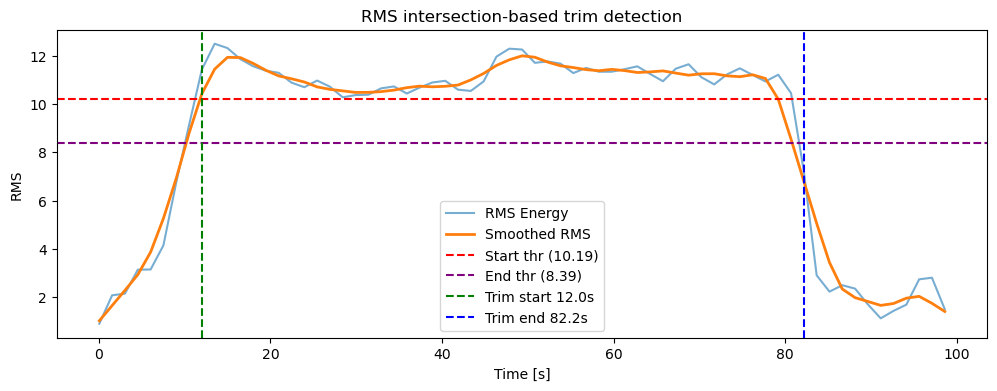

sample rate 100.43619412132131
step 502
stride 251
  Trim 12.55 → 80.02, 26 windows (multi-file) saved in c:\Users\ozdep\Documents\data analytics\data\trimmed_data\running\Ozde_Run_2

=== Processing running | Folder: Ozde_Run_3 ===


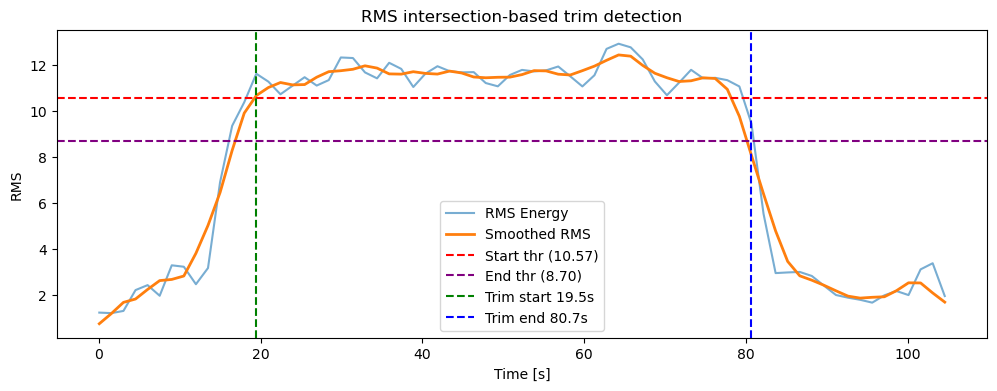

sample rate 100.44658957041499
step 502
stride 251
  Trim 20.05 → 80.02, 23 windows (multi-file) saved in c:\Users\ozdep\Documents\data analytics\data\trimmed_data\running\Ozde_Run_3

=== Processing running | Folder: Ozde_Run_4 ===


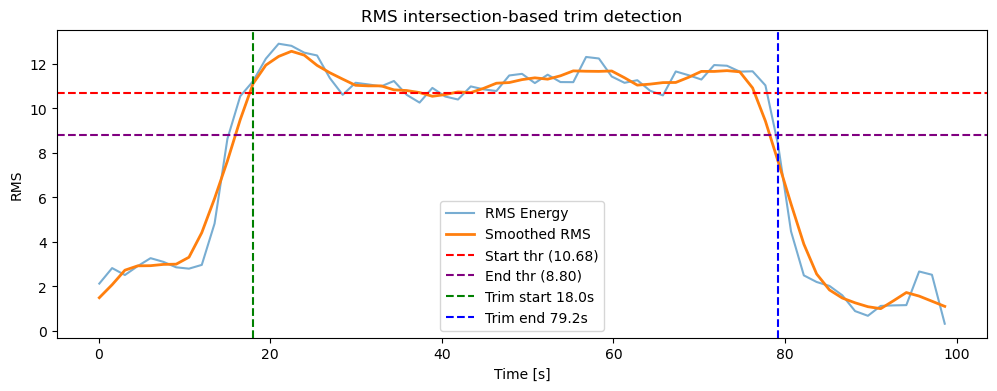

sample rate 100.4563522061608
step 502
stride 251
  Trim 17.55 → 77.52, 23 windows (multi-file) saved in c:\Users\ozdep\Documents\data analytics\data\trimmed_data\running\Ozde_Run_4

=== Processing running | Folder: Ozde_Run_5 ===


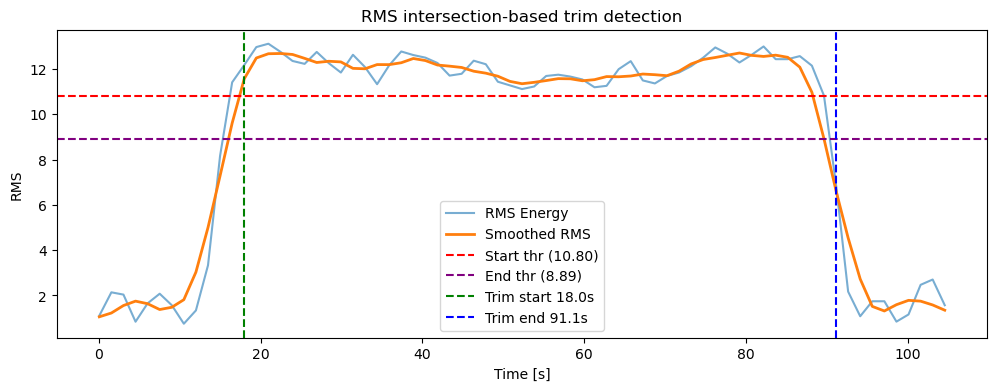

sample rate 100.45930629871526
step 502
stride 251
  Trim 17.54 → 90.00, 28 windows (multi-file) saved in c:\Users\ozdep\Documents\data analytics\data\trimmed_data\running\Ozde_Run_5


In [ ]:

# Add project root to sys.path 
sys.path.append(os.path.abspath(".."))

# Reload module to ensure notebook sees latest changes
import src.preprocessing
importlib.reload(src.preprocessing) # for debugging 

from src.preprocessing import process_folder, detect_trim_bounds_rms_intersection

# Root for saving 
trimmed_root = os.path.abspath("../data/trimmed_data")

# run single-file processing
import shutil

activity = "running"
for folder_name, folder_data in all_data[activity].items():
    out_dir = os.path.join(trimmed_root, activity, folder_name)

    # Remove old processed folder if it exists
    if os.path.exists(out_dir):
        print(f"Reprocessing {activity} | Folder: {folder_name} (removing old results)")
        shutil.rmtree(out_dir)

    else:
        print(f"\n Processing {activity} | Folder: {folder_name}")

    # 1. Single-file (Accelerometer only)
    df = folder_data["Accelerometer.csv"]

    time = df["seconds_elapsed"].values
    y_values = df["y"].values
    sample_rate = len(time) / (time[-1] - time[0])
    window_size = 3  # seconds
    step = int(window_size * sample_rate)
    stride = int(step * 0.5)  # 50% overlap

    trim_start, trim_end = detect_trim_bounds_rms_intersection(
        time,
        y_values,
        step,
        stride,
        frac_start=0.85,   # start when RMS passes 20% of peak
        frac_end=0.7,     # end when RMS falls below 20% of peak
        smooth=5,
        debug=True
    )


    # Now actually process the folder
    trim_start, trim_end, n_win, out_dir = process_folder(folder_data, activity, folder_name, trimmed_root)
    print(f"  Trim {trim_start:.2f} → {trim_end:.2f}, {n_win} windows (multi-file) saved in {out_dir}")


Apply the same process to the walking class.

Reprocessing walking | Folder: Berkan_Walk_1 (removing old results)


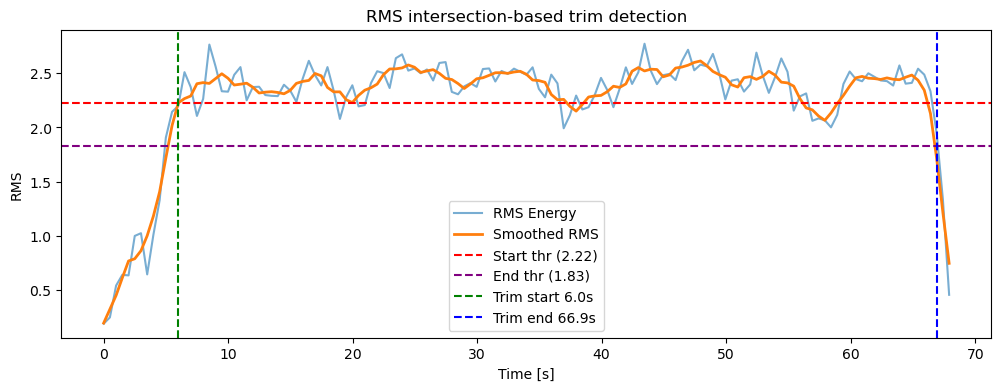

sample rate 100.17942029915993
step 500
stride 250
  Trim 7.50 → 62.41, 21 windows (multi-file) saved in c:\Users\ozdep\Documents\data analytics\data\trimmed_data\walking\Berkan_Walk_1
Reprocessing walking | Folder: Liya_Walk_1 (removing old results)


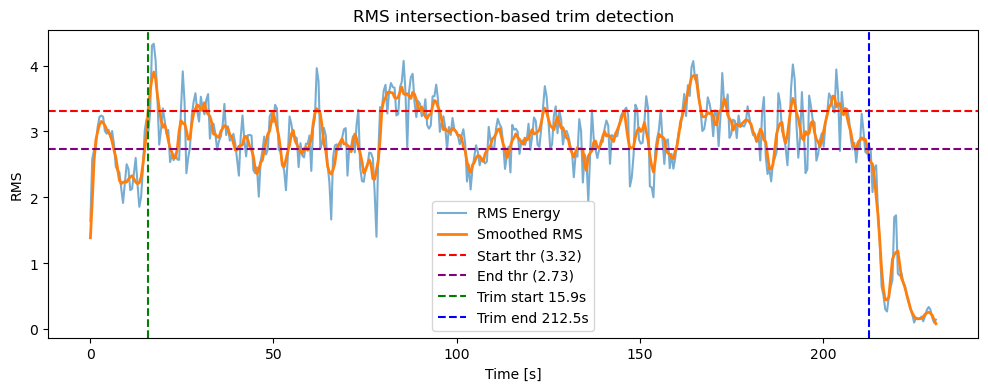

sample rate 99.16264521584374
step 495
stride 247
  Trim 12.49 → 211.77, 78 windows (multi-file) saved in c:\Users\ozdep\Documents\data analytics\data\trimmed_data\walking\Liya_Walk_1
Reprocessing walking | Folder: Liya_Walk_2 (removing old results)


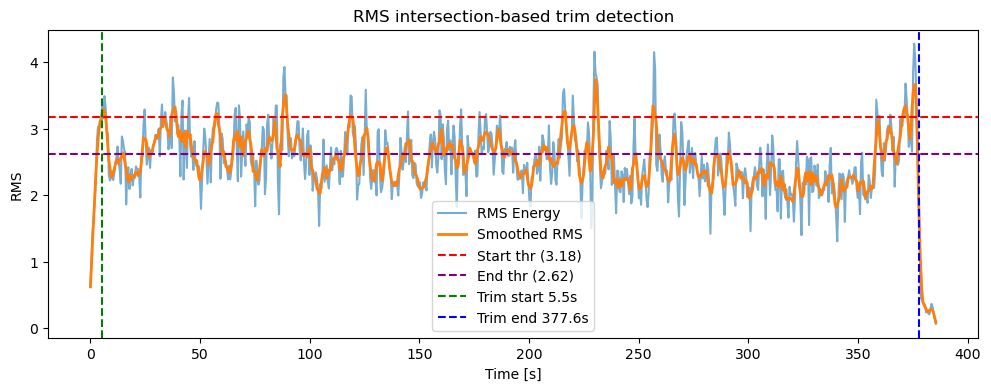

sample rate 99.16484360922252
step 495
stride 247
  Trim 5.05 → 376.19, 147 windows (multi-file) saved in c:\Users\ozdep\Documents\data analytics\data\trimmed_data\walking\Liya_Walk_2
Reprocessing walking | Folder: Ozde_Walk_1 (removing old results)


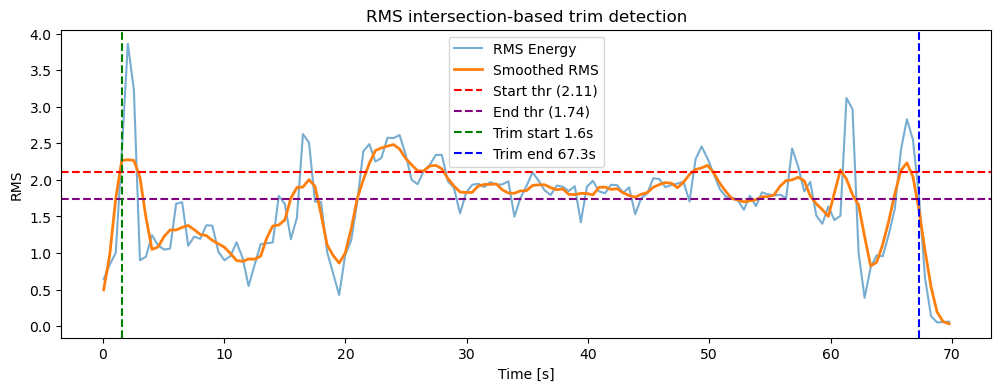

sample rate 100.41714957922062
step 502
stride 251
  Trim 17.56 → 62.56, 17 windows (multi-file) saved in c:\Users\ozdep\Documents\data analytics\data\trimmed_data\walking\Ozde_Walk_1
Reprocessing walking | Folder: Ozde_Walk_2 (removing old results)


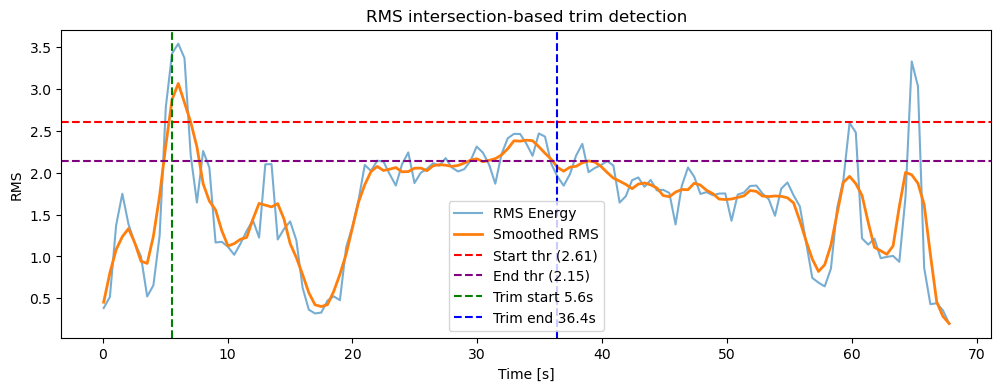

sample rate 100.43085337680718
step 502
stride 251
  Trim 5.08 → 60.06, 21 windows (multi-file) saved in c:\Users\ozdep\Documents\data analytics\data\trimmed_data\walking\Ozde_Walk_2


In [5]:

# Root for saving 
trimmed_root = os.path.abspath("../data/trimmed_data")

# run single-file processing
import shutil

activity = "walking"
for folder_name, folder_data in all_data[activity].items():
    out_dir = os.path.join(trimmed_root, activity, folder_name)

    # Remove old processed folder if it exists
    if os.path.exists(out_dir):
        print(f"Reprocessing {activity} | Folder: {folder_name} (removing old results)")
        shutil.rmtree(out_dir)

    else:
        print(f"\n Processing {activity} | Folder: {folder_name} ")

    #  Single-file (Accelerometer only)
    df = folder_data["Accelerometer.csv"]

    time = df["seconds_elapsed"].values
    y_values = df["y"].values
    sample_rate = len(time) / (time[-1] - time[0])
    window_size = 1  # seconds
    step = int(window_size * sample_rate)
    stride = int(step * 0.5)  # 50% overlap

    trim_start, trim_end = detect_trim_bounds_rms_intersection(
        time,
        y_values,
        step,
        stride,
        frac_start=0.85,   # start when RMS passes 20% of peak
        frac_end=0.7,     # end when RMS falls below 20% of peak
        smooth=5,
        debug=True
    )

    # Now actually process the folder
    trim_start, trim_end, n_win, out_dir = process_folder(folder_data, activity, folder_name, trimmed_root)
    print(f"  Trim {trim_start:.2f} → {trim_end:.2f}, {n_win} windows (multi-file) saved in {out_dir}")


For the trimming of stairs the gravitation.csv file was used to analyze the points where the acitivity starts and stops. 


 Processing stairs | Folder: Berkan_Stairs_1 


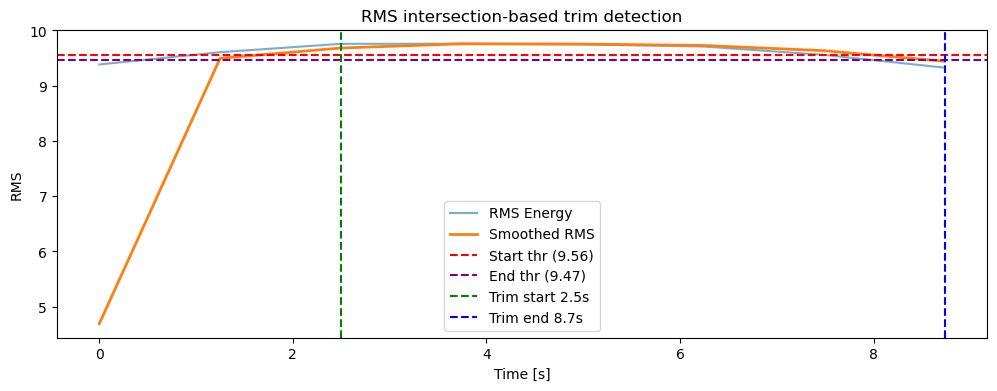

Berkan_Stairs_1: Trim 2.50 → 8.74


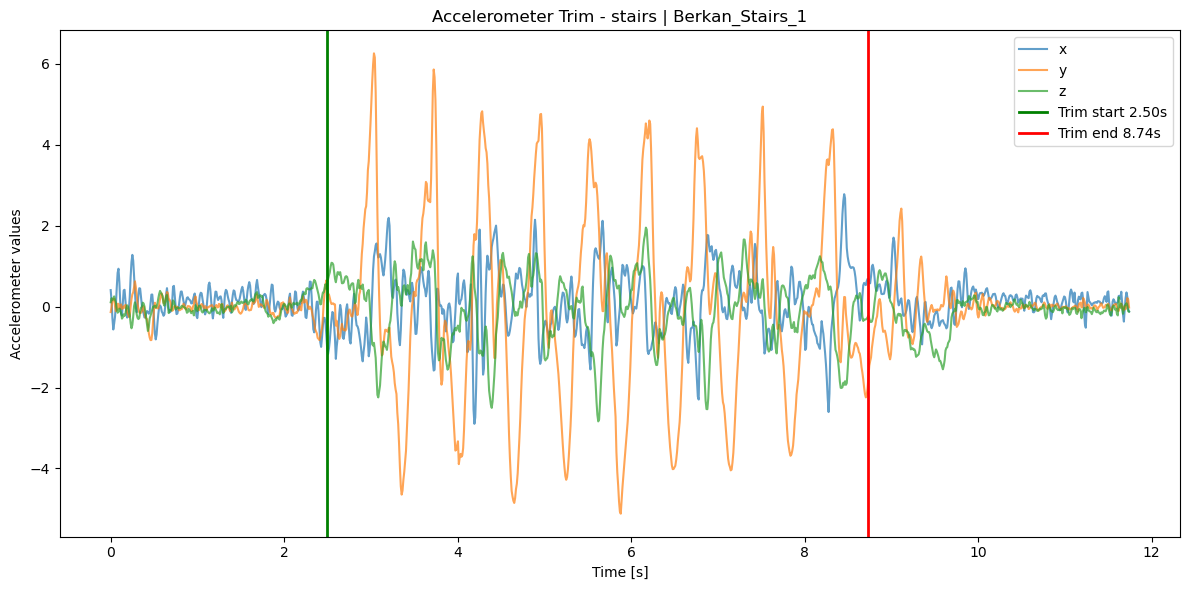

Saved accelerometer plot to c:\Users\ozdep\Documents\data analytics\data\trimmed_data\stairs\Berkan_Stairs_1\Berkan_Stairs_1_accelerometer_trim.png


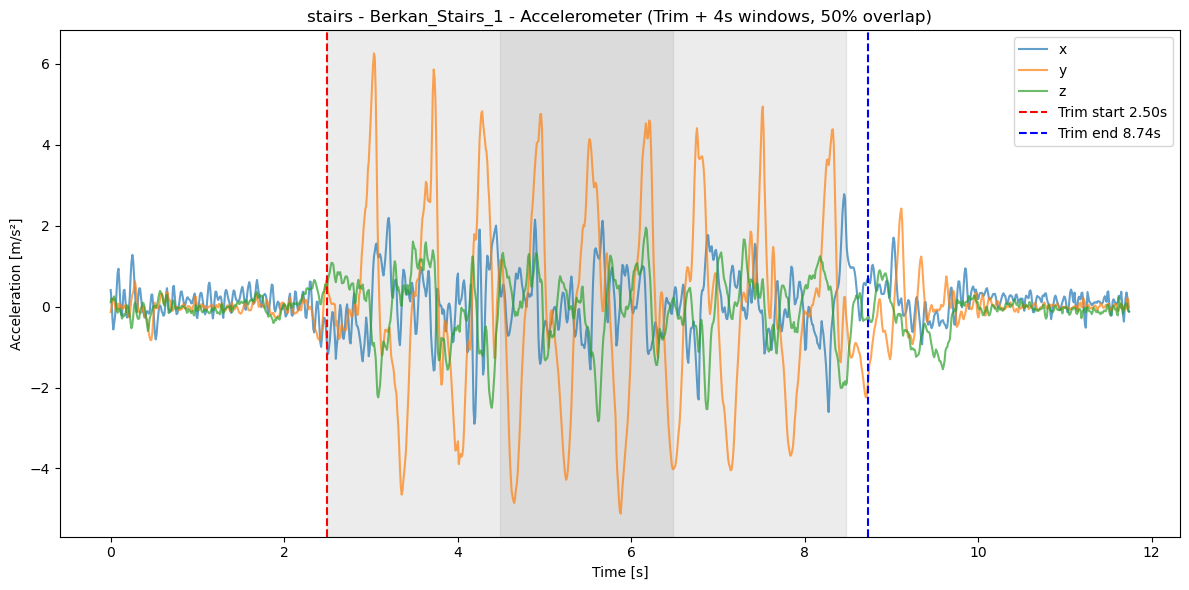

Saved summary plot to c:\Users\ozdep\Documents\data analytics\data\trimmed_data\stairs\Berkan_Stairs_1\Berkan_Stairs_1_summary_plot.png

 Processing stairs | Folder: Berkan_Stairs_2 


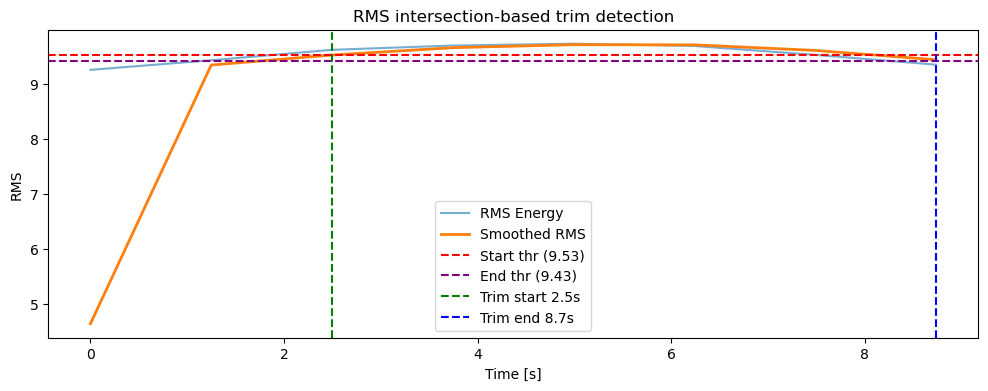

Berkan_Stairs_2: Trim 2.50 → 8.74


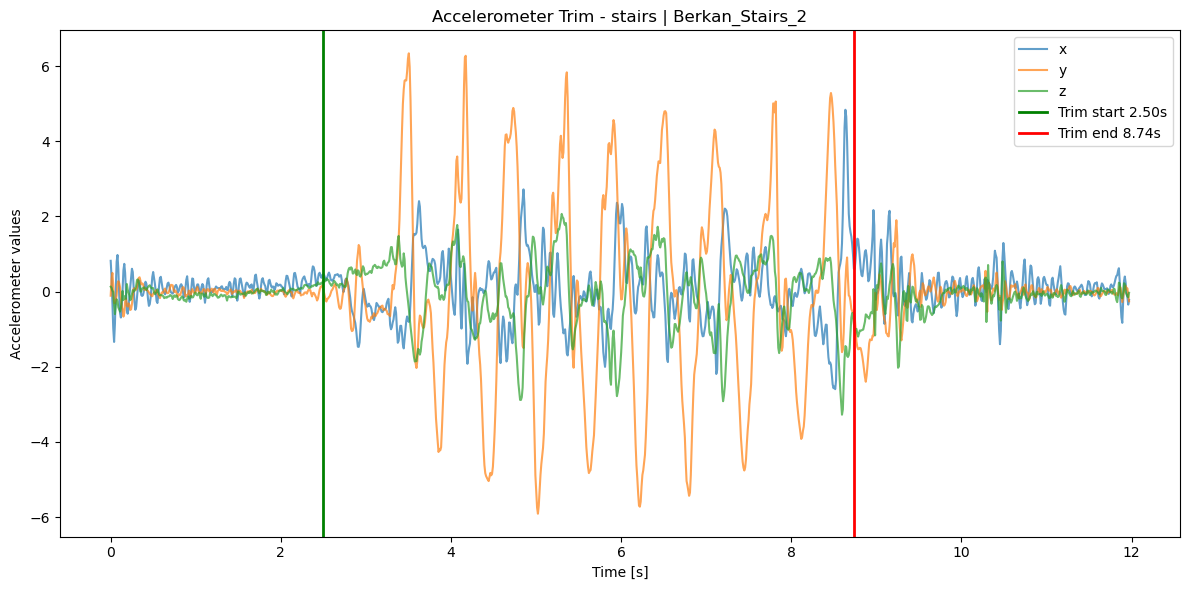

Saved accelerometer plot to c:\Users\ozdep\Documents\data analytics\data\trimmed_data\stairs\Berkan_Stairs_2\Berkan_Stairs_2_accelerometer_trim.png


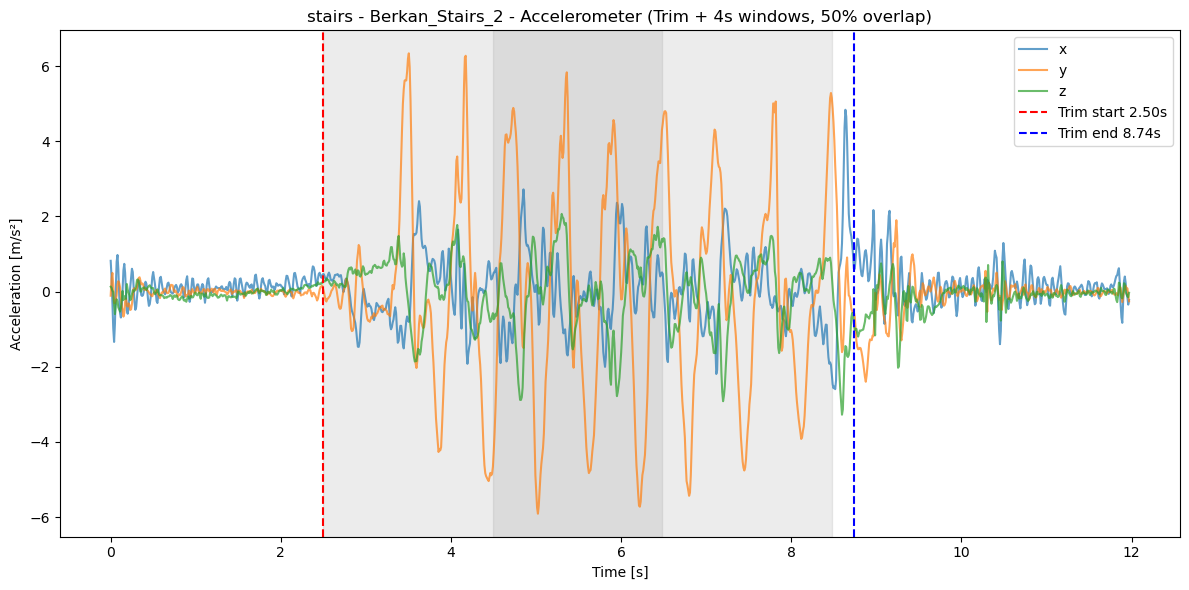

Saved summary plot to c:\Users\ozdep\Documents\data analytics\data\trimmed_data\stairs\Berkan_Stairs_2\Berkan_Stairs_2_summary_plot.png

 Processing stairs | Folder: Berkan_Stairs_3 


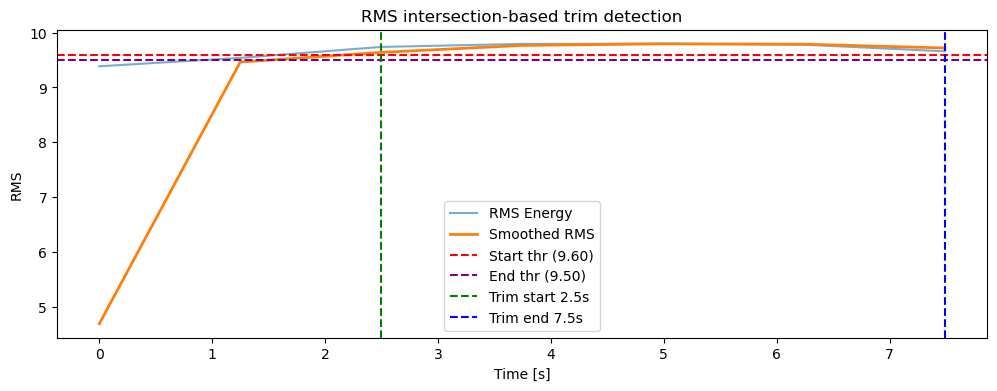

Berkan_Stairs_3: Trim 2.50 → 7.49


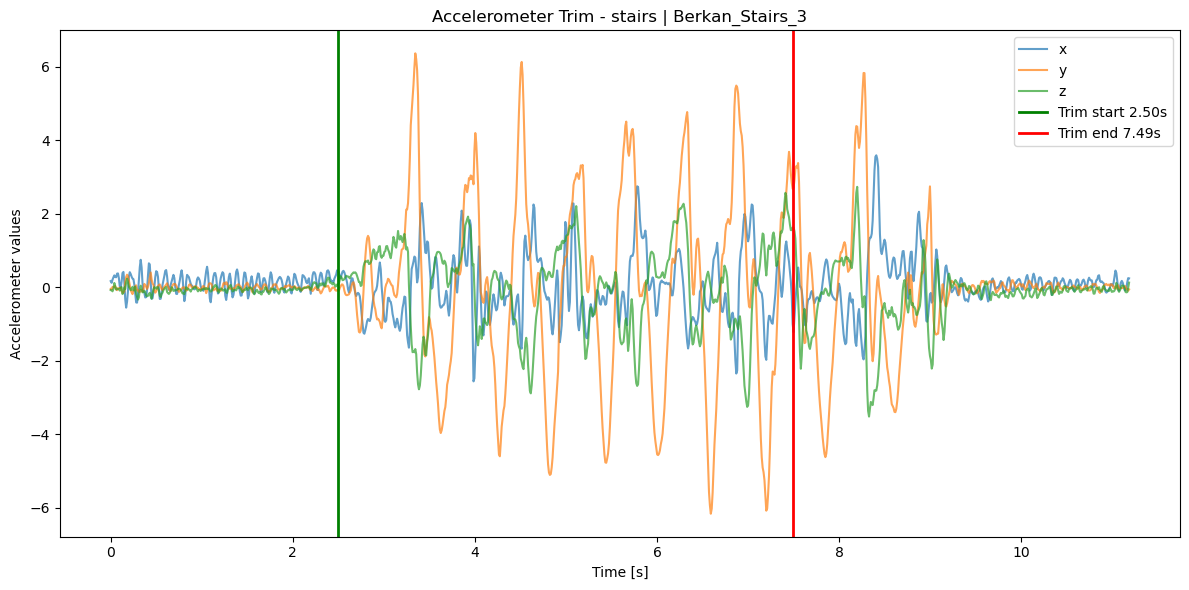

Saved accelerometer plot to c:\Users\ozdep\Documents\data analytics\data\trimmed_data\stairs\Berkan_Stairs_3\Berkan_Stairs_3_accelerometer_trim.png


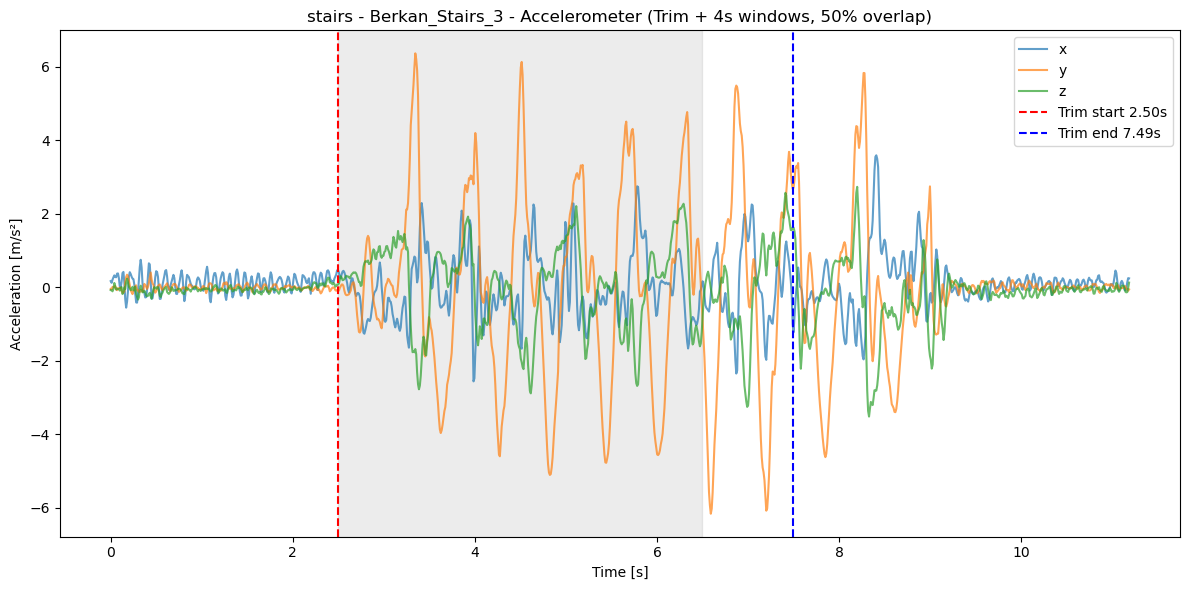

Saved summary plot to c:\Users\ozdep\Documents\data analytics\data\trimmed_data\stairs\Berkan_Stairs_3\Berkan_Stairs_3_summary_plot.png

 Processing stairs | Folder: Berkan_Stairs_4 


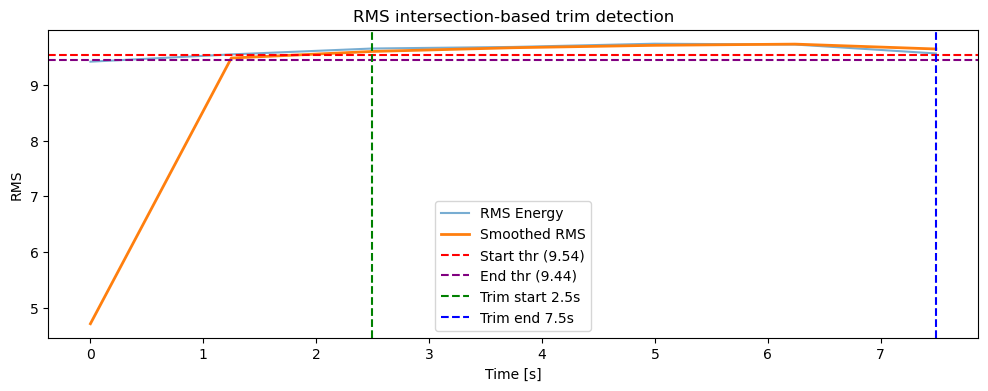

Berkan_Stairs_4: Trim 2.50 → 7.49


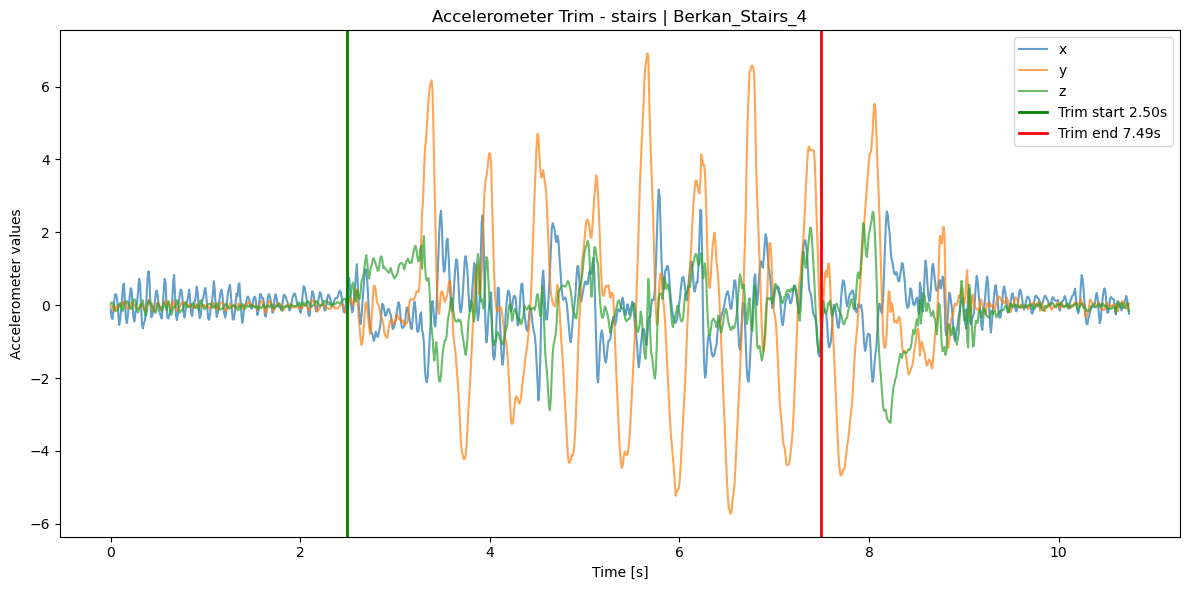

Saved accelerometer plot to c:\Users\ozdep\Documents\data analytics\data\trimmed_data\stairs\Berkan_Stairs_4\Berkan_Stairs_4_accelerometer_trim.png


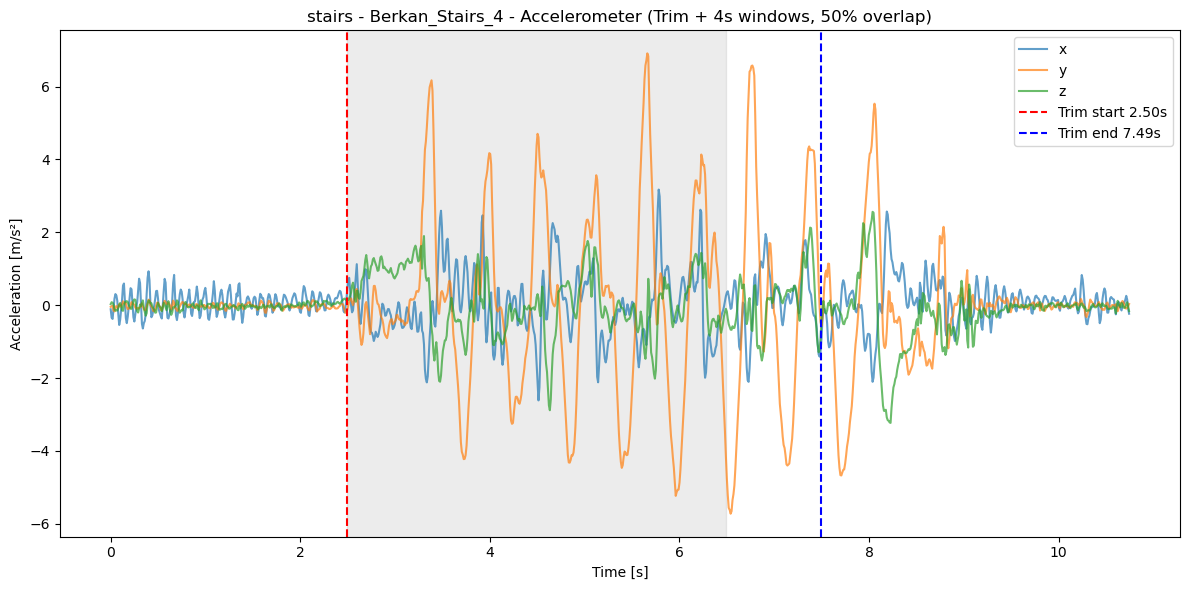

Saved summary plot to c:\Users\ozdep\Documents\data analytics\data\trimmed_data\stairs\Berkan_Stairs_4\Berkan_Stairs_4_summary_plot.png

 Processing stairs | Folder: Liya_Stairs_1 


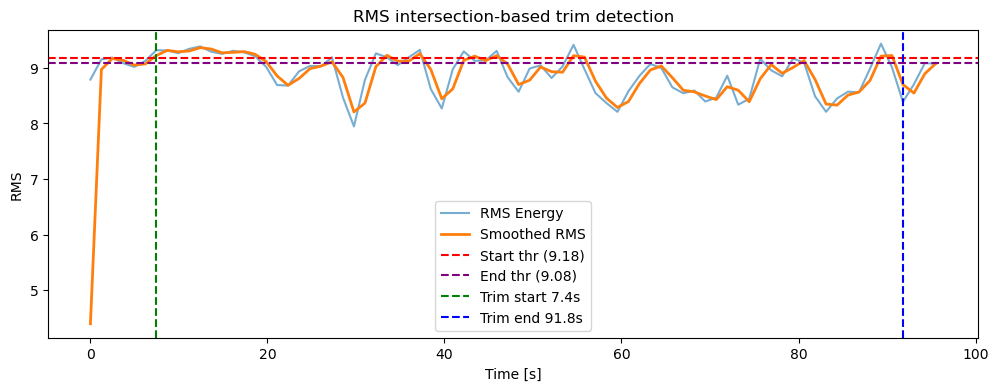

Liya_Stairs_1: Trim 7.44 → 91.80


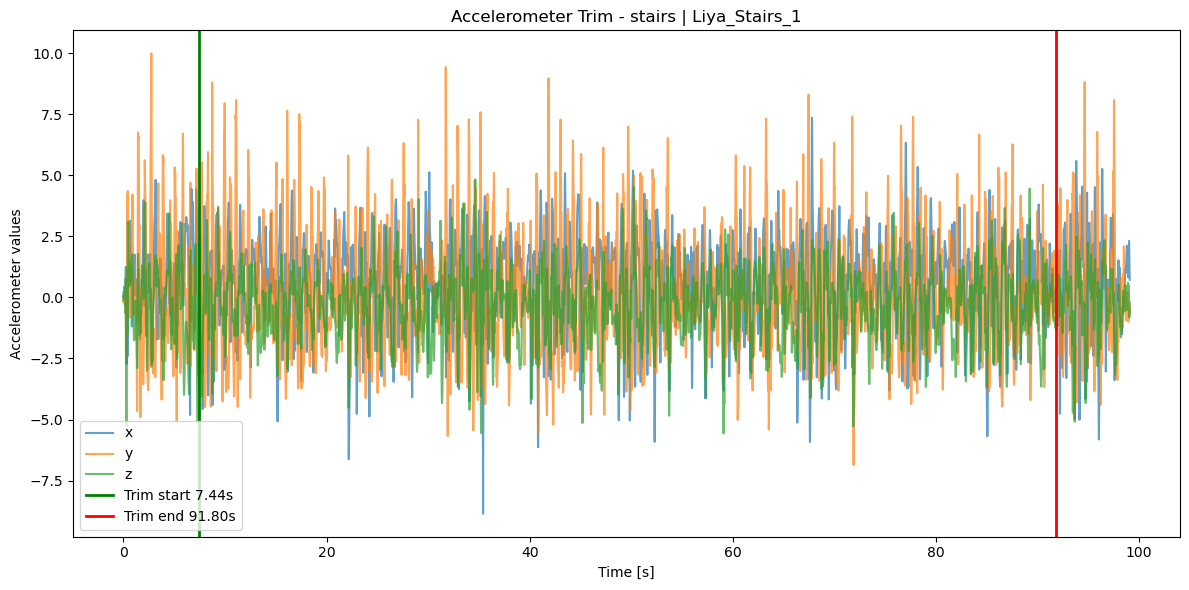

Saved accelerometer plot to c:\Users\ozdep\Documents\data analytics\data\trimmed_data\stairs\Liya_Stairs_1\Liya_Stairs_1_accelerometer_trim.png


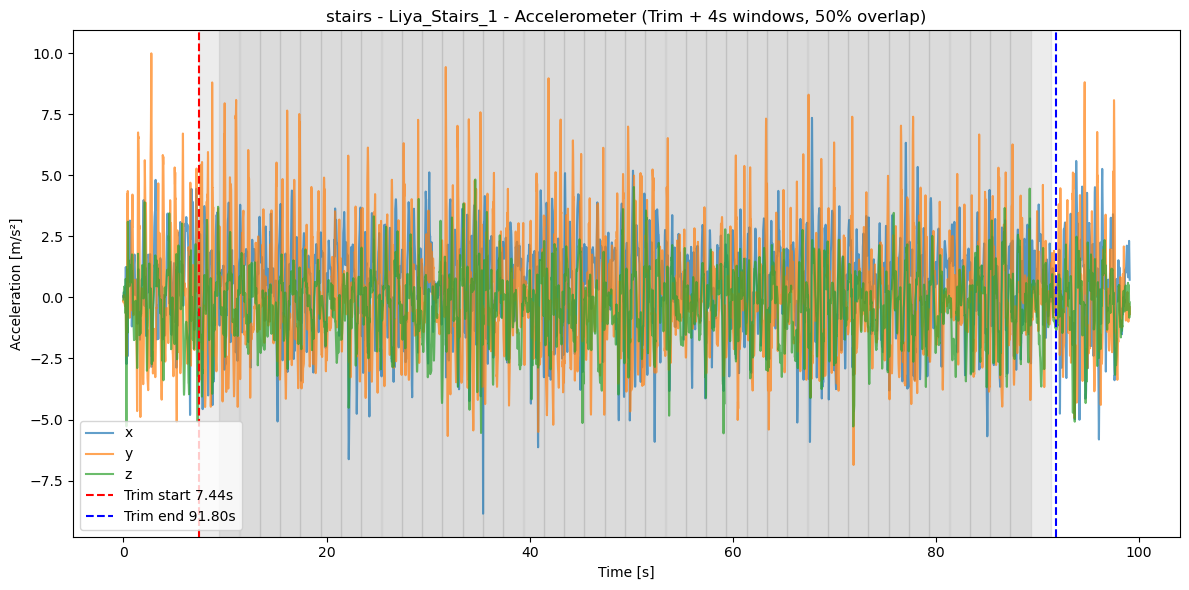

Saved summary plot to c:\Users\ozdep\Documents\data analytics\data\trimmed_data\stairs\Liya_Stairs_1\Liya_Stairs_1_summary_plot.png

 Processing stairs | Folder: Ozde_Stairs_2 


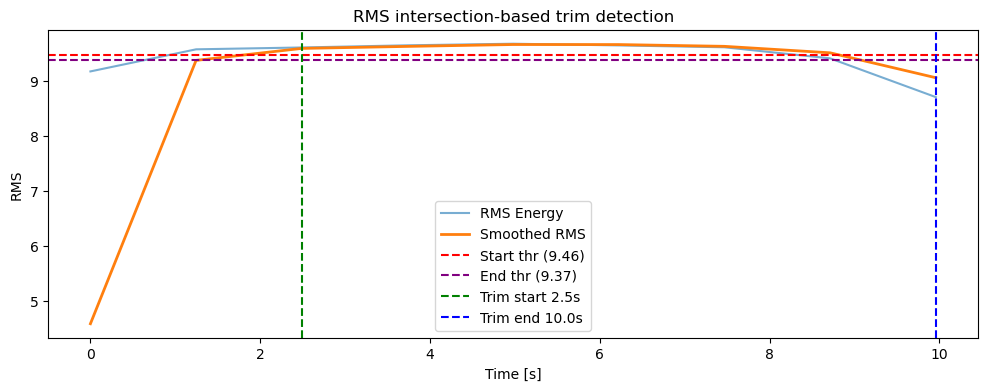

Ozde_Stairs_2: Trim 2.49 → 9.96


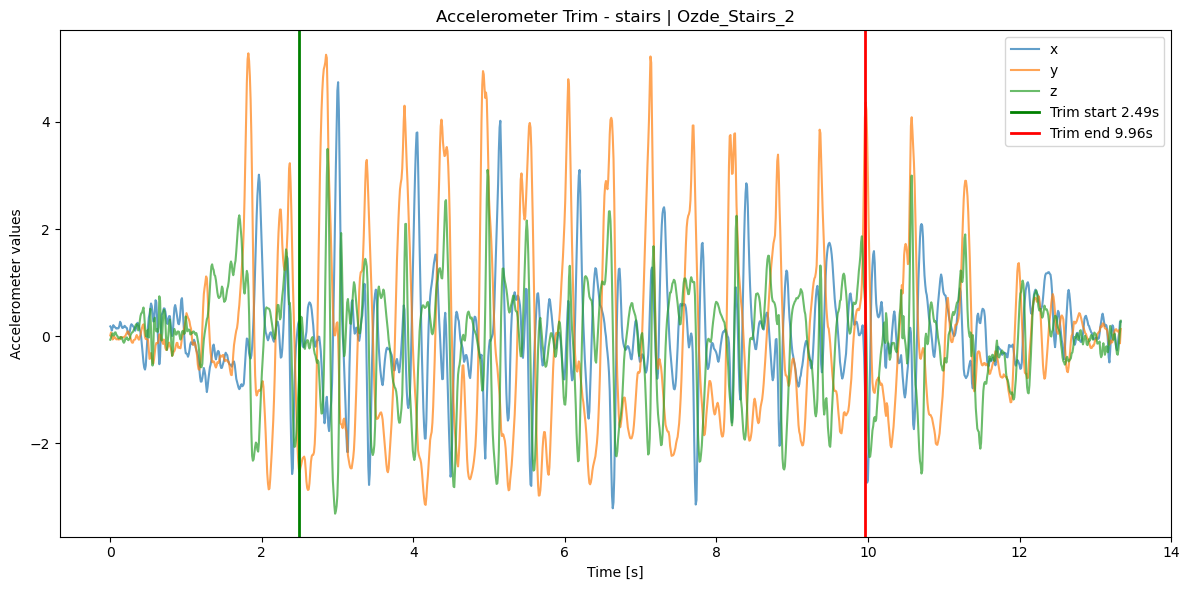

Saved accelerometer plot to c:\Users\ozdep\Documents\data analytics\data\trimmed_data\stairs\Ozde_Stairs_2\Ozde_Stairs_2_accelerometer_trim.png


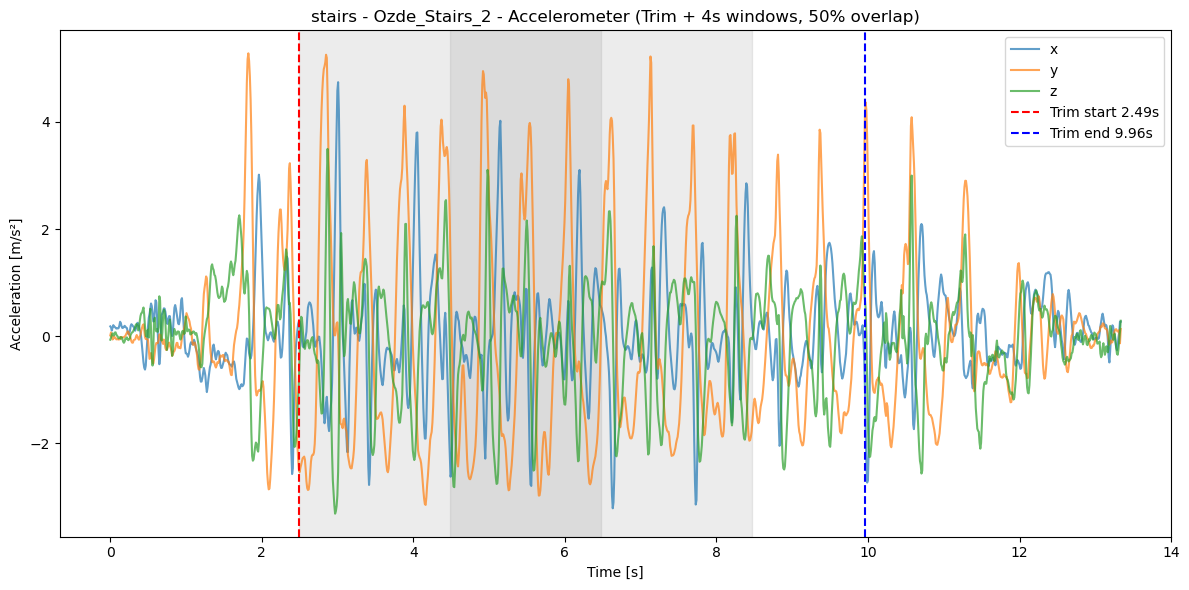

Saved summary plot to c:\Users\ozdep\Documents\data analytics\data\trimmed_data\stairs\Ozde_Stairs_2\Ozde_Stairs_2_summary_plot.png

 Processing stairs | Folder: Ozde_Stairs_4 


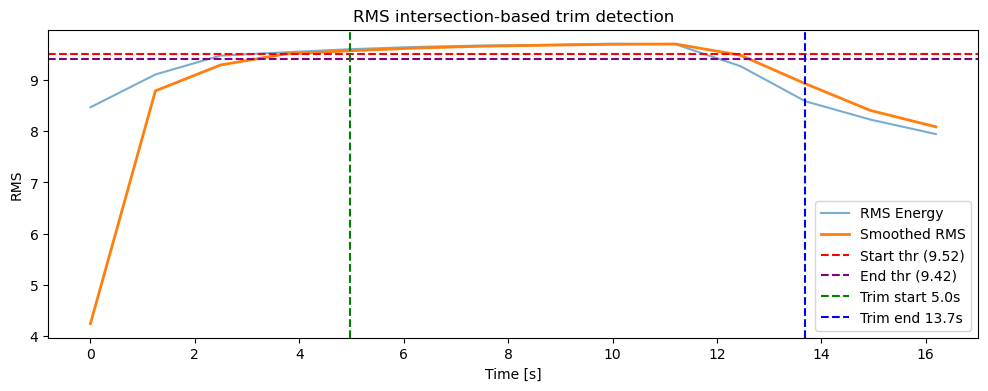

Ozde_Stairs_4: Trim 4.98 → 13.70


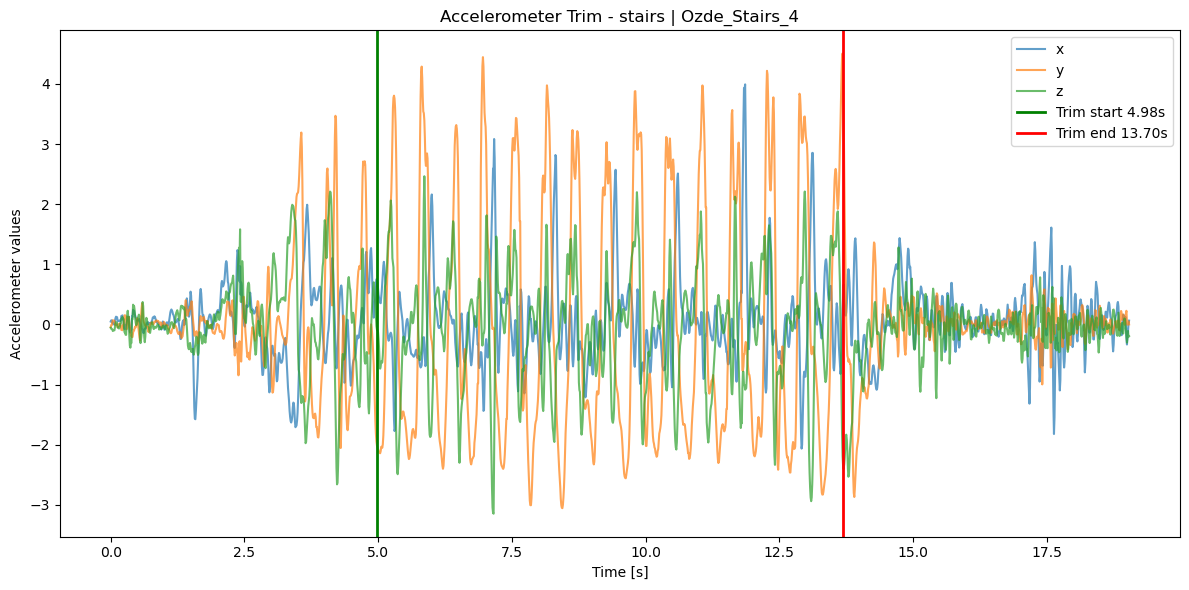

Saved accelerometer plot to c:\Users\ozdep\Documents\data analytics\data\trimmed_data\stairs\Ozde_Stairs_4\Ozde_Stairs_4_accelerometer_trim.png


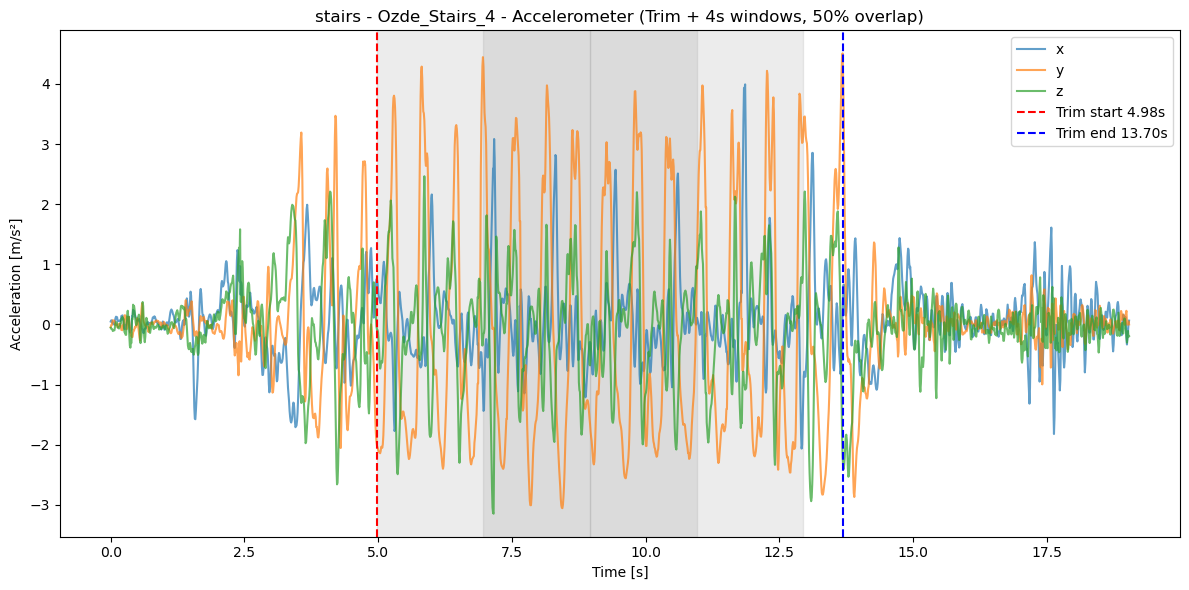

Saved summary plot to c:\Users\ozdep\Documents\data analytics\data\trimmed_data\stairs\Ozde_Stairs_4\Ozde_Stairs_4_summary_plot.png


In [6]:

activity = "stairs"
for folder_name, folder_data in all_data[activity].items():
    out_dir = os.path.join(trimmed_root, activity, folder_name)

    if os.path.exists(out_dir):
        print(f"Reprocessing {activity} | Folder: {folder_name} (removing old results)")
        shutil.rmtree(out_dir)
    else:
        print(f"\n Processing {activity} | Folder: {folder_name} ")

    os.makedirs(out_dir, exist_ok=True)

    # Normalize time across all CSVs in this folder 
    for name, df in folder_data.items():
        if "seconds_elapsed" in df.columns:
            df["seconds_elapsed"] = df["seconds_elapsed"] - df["seconds_elapsed"].iloc[0]

    # Detect trim from Gravity.csv 
    df_gravity = folder_data["Gravity.csv"]
    time = df_gravity["seconds_elapsed"].values
    y_values = df_gravity["y"].values

    sample_rate = len(time) / (time[-1] - time[0])
    window_size = 2.5  # seconds
    step = int(window_size * sample_rate)
    stride = int(step * 0.5)  # 50% overlap

    trim_start, trim_end = detect_trim_bounds_rms_intersection(
        time,
        y_values,
        step,
        stride,
        frac_start=0.98,
        frac_end=0.97,
        smooth=2,
        debug=True
    )

    print(f"{folder_name}: Trim {trim_start:.2f} → {trim_end:.2f}")


    # Plot accelerometer with trim markers
    df_acc = folder_data["Accelerometer.csv"]
    plt.figure(figsize=(12, 6))
    plt.plot(df_acc["seconds_elapsed"], df_acc["x"], label="x", alpha=0.7)
    plt.plot(df_acc["seconds_elapsed"], df_acc["y"], label="y", alpha=0.7)
    plt.plot(df_acc["seconds_elapsed"], df_acc["z"], label="z", alpha=0.7)

    plt.axvline(trim_start, color="g", linewidth=2, label=f"Trim start {trim_start:.2f}s")
    plt.axvline(trim_end, color="r", linewidth=2, label=f"Trim end {trim_end:.2f}s")

    plt.title(f"Accelerometer Trim - {activity} | {folder_name}")
    plt.xlabel("Time [s]")
    plt.ylabel("Accelerometer values")
    plt.legend()
    plt.tight_layout()

    plot_path = os.path.join(out_dir, f"{folder_name}_accelerometer_trim.png")
    plt.savefig(plot_path, dpi=150)
    plt.show()
    print(f"Saved accelerometer plot to {plot_path}")

    # Slice all raw CSVs into windows (per window folder) 
    window_size = 4  # seconds
    step = int(window_size * sample_rate)
    stride = int(step * 0.5)

    # Use accelerometer to decide window ranges
    df_acc_trimmed = df_acc[(df_acc["seconds_elapsed"] >= trim_start) &
                            (df_acc["seconds_elapsed"] <= trim_end)]
    acc_time = df_acc_trimmed["seconds_elapsed"].values
    start_idx = np.searchsorted(acc_time, trim_start)
    end_idx = np.searchsorted(acc_time, trim_end)

    window_ranges = []
    for i, start in enumerate(range(start_idx, end_idx - step + 1, stride)):
        end = start + step

        # Define a window directory
        win_dir = os.path.join(out_dir, f"window_{i+1}")
        os.makedirs(win_dir, exist_ok=True)

        # Save trimmed data for all files into this window
        for file_name, df in folder_data.items():
            if "seconds_elapsed" not in df.columns:
                continue

            df_trimmed = df[(df["seconds_elapsed"] >= trim_start) &
                            (df["seconds_elapsed"] <= trim_end)]

            window_df = df_trimmed.iloc[start:end]
            if len(window_df) < step:
                continue

            file_out = os.path.join(win_dir, file_name)
            window_df.to_csv(file_out, index=False)

        # Record ranges for summary plot
        win_start = df_acc_trimmed.iloc[start]["seconds_elapsed"]
        win_end = df_acc_trimmed.iloc[end-1]["seconds_elapsed"]
        window_ranges.append((win_start, win_end))

    # Summary plot with shaded windows 
    plt.figure(figsize=(12, 6))
    plt.plot(df_acc["seconds_elapsed"], df_acc["x"], label="x", alpha=0.7)
    plt.plot(df_acc["seconds_elapsed"], df_acc["y"], label="y", alpha=0.7)
    plt.plot(df_acc["seconds_elapsed"], df_acc["z"], label="z", alpha=0.7)

    plt.axvline(trim_start, color="red", linestyle="--", label=f"Trim start {trim_start:.2f}s")
    plt.axvline(trim_end, color="blue", linestyle="--", label=f"Trim end {trim_end:.2f}s")

    for win_start, win_end in window_ranges:
        plt.axvspan(win_start, win_end, color="gray", alpha=0.15)

    plt.title(f"{activity} - {folder_name} - Accelerometer (Trim + 4s windows, 50% overlap)")
    plt.xlabel("Time [s]")
    plt.ylabel("Acceleration [m/s²]")
    plt.legend()
    plt.tight_layout()

    summary_path = os.path.join(out_dir, f"{folder_name}_summary_plot.png")
    plt.savefig(summary_path, dpi=150)
    plt.show()
    print(f"Saved summary plot to {summary_path}")



- For single-instance activities (sit-down / stand-up):
Below code trimmes down the single-instance activities (sit-down / stand-up) down to 5 seconds centering the activity in that 5 second duration.

In [ ]:
WINDOW_SIZE = 4.0 #Seconds

results = trim_sitdown_standup(RAW_BASE, TRIMMED_BASE, seconds=WINDOW_SIZE)

Done. Processed: 60 | Skipped: 0


# I will fill in these cells later, providing an explanation of how the complete dataset DataFrame was created. I haven’t written these cells yet. The code and explanation is ready just didn't have the time to fill in (Berkan)

Dowload the dataset

In [19]:
df = pd.read_csv(PROJECT_ROOT / "dataset.csv")
df.head()

,activity,acc_corr_x_y,acc_corr_x_z,acc_corr_y_z,acc_mag_dom_freq,acc_mag_iqr,acc_mag_kurtosis,acc_mag_max,acc_mag_mean,acc_mag_median,...,gyro_z_max,gyro_z_mean,gyro_z_median,gyro_z_min,gyro_z_rms,gyro_z_skew,gyro_z_spec_centroid,gyro_z_spec_energy,gyro_z_spec_entropy,gyro_z_std
0,running,-0.281075,-0.043821,-0.133161,5.0,6.283983,-0.618317,19.120742,9.154614,9.208327,...,0.877164,-0.055802,-0.069478,-1.176092,0.391531,-0.328947,4.852351,5.234881,3.243084,0.388181
1,running,-0.309418,-0.046545,-0.123186,5.0,5.918809,-0.662986,19.120742,9.137869,9.557943,...,0.851426,-0.057462,-0.000974,-1.182521,0.435021,-0.625667,3.094587,13.222227,2.866708,0.431929
2,running,-0.388308,0.001577,-0.075829,5.0,5.876315,-0.803472,17.390812,8.872321,9.274902,...,0.874958,0.017195,0.082649,-1.182521,0.450887,-0.496044,3.284412,12.602182,2.719130,0.451312
3,running,-0.363118,0.082110,-0.133594,5.0,5.718731,-0.714783,17.458686,9.289376,9.777345,...,0.952842,0.040561,0.107907,-1.405989,0.500506,-0.557832,3.225312,14.981243,2.694279,0.499693
4,running,-0.320655,0.035273,-0.190649,5.0,5.610227,-0.529571,18.529506,9.455079,10.000083,...,1.033535,0.018036,0.095053,-1.405989,0.537932,-0.596362,2.514952,13.633110,2.191981,0.538528


# Training / PCA etc.